# Weibull (Type III): Bounded Extremes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_weibull_bounded.ipynb)

This notebook walks the canonical block-maxima → GEVD pipeline on a parent with a *finite right endpoint*. The Fisher–Tippett–Gnedenko theorem says the limit law is a Reverse-Weibull (GEVD with $\xi < 0$); fitting it correctly is essential whenever physics or biology imposes a hard cap on the variable.

The headline quantity here is **the upper endpoint** $x_{\sup} = \mu - \sigma/\xi$ — a posterior summary of the largest possible value. In reliability and actuarial work this is often the *only* quantity reported, since the entire return-level curve asymptotes to it.

We compare against a misspecified Gumbel ($\xi = 0$, unbounded) on the same maxima and quantify how far the misspecified return-level curve runs above the true cap.

**Math content**

- The Reverse-Weibull PDF and CDF, the bounded support $\mu - \sigma/\xi$.
- The Weibull domain of attraction: parents with finite right endpoint $x_F < \infty$.
- Posterior on the upper endpoint, including the posterior predictive max distribution.
- Why misspecified Gumbel over-predicts the long-period return level.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax.distributions import GumbelType1GEVD, WeibullType3GEVD
from xtremax.extraction import temporal_block_maxima


numpyro.set_host_device_count(2)
KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,xarray,xtremax",
    )
else:
    print("watermark extension not loaded (IPython or watermark package missing)")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
numpy     : 2.4.4
matplotlib: 3.10.8
numpyro   : 0.19.0
xarray    : 2026.4.0
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. The Weibull domain of attraction

The third Fisher–Tippett–Gnedenko regime is for parents with a **finite right endpoint**

$$
x_F \;:=\; \sup\{x : F(x) < 1\} \;<\; \infty.
$$

> $F$ lies in the Weibull domain of attraction $\mathcal{D}(G_\xi)$ with $\xi < 0$ iff $\bar F(x_F - 1/u)$ is regularly varying at $\infty$ with index $-1/\xi$ (note $\xi < 0$ here, so $-1/\xi > 0$).

Geometrically: as you approach the right endpoint, the survival function vanishes like a power of the *distance to the endpoint*. This corresponds to phenomena where a bounded mechanism — material strength, biological lifespan, hardware capacity — sets a hard ceiling.

**Reverse-Weibull PDF and CDF.** With $z = (x - \mu)/\sigma$ and $\xi < 0$,

$$
F(x;\,\mu,\sigma,\xi) = \exp\!\bigl[-(1 + \xi z)^{-1/\xi}\bigr],\qquad x \le \mu - \sigma/\xi,
$$

$$
f(x;\,\mu,\sigma,\xi) = \tfrac{1}{\sigma}(1 + \xi z)^{-(1/\xi + 1)}\,F(x).
$$

The same Coles formula as Fréchet, restricted to $\xi < 0$. The crucial structural difference is the *upper* support boundary:

$$
\boxed{\,x_{\sup} \;=\; \mu - \sigma/\xi \;=\; \mu + \sigma/|\xi|\,}
$$

As $\xi \to 0^-$ this boundary recedes to $+\infty$ and we recover the Gumbel limit. As $\xi \to -\infty$ the support collapses around $\mu$.

**All moments are finite** because the support is bounded. The mean is

$$
\mathbb{E}[X] = \mu + \frac{\sigma}{\xi}\bigl(\Gamma(1-\xi) - 1\bigr), \qquad \xi < 0,
$$

where $\Gamma$ is the gamma function. (For $\xi < 0$, $1-\xi > 1$, so $\Gamma(1-\xi)$ is well-defined.)

**Return level.** Same closed form as Fréchet,

$$
z_T = \mu + \frac{\sigma}{\xi}\Bigl[\bigl(-\log(1 - 1/T)\bigr)^{-\xi} - 1\Bigr],
$$

but the return-level *curve* is qualitatively different: as $T \to \infty$, $-\log(1 - 1/T) \to 0$ and $(-\log(1 - 1/T))^{-\xi} \to 0$ (since $-\xi > 0$). Therefore

$$
z_T \;\xrightarrow[T \to \infty]{}\; \mu - \sigma/\xi \;=\; x_{\sup}.
$$

On a $\log T$ axis the curve *flattens* and asymptotes to the upper endpoint — a visual signature unique to the Weibull regime.

## 2. Synthetic capped daily series

We simulate a process whose values are bounded above by a hard cap $x_F = 100$. The "noisy" mechanism is a beta-like draw that lives on $[0, 100]$ and concentrates near $90$, with occasional small dips. The annual maxima will sit just below $100$ with a left tail extending downward — exactly the Weibull-attracting picture.

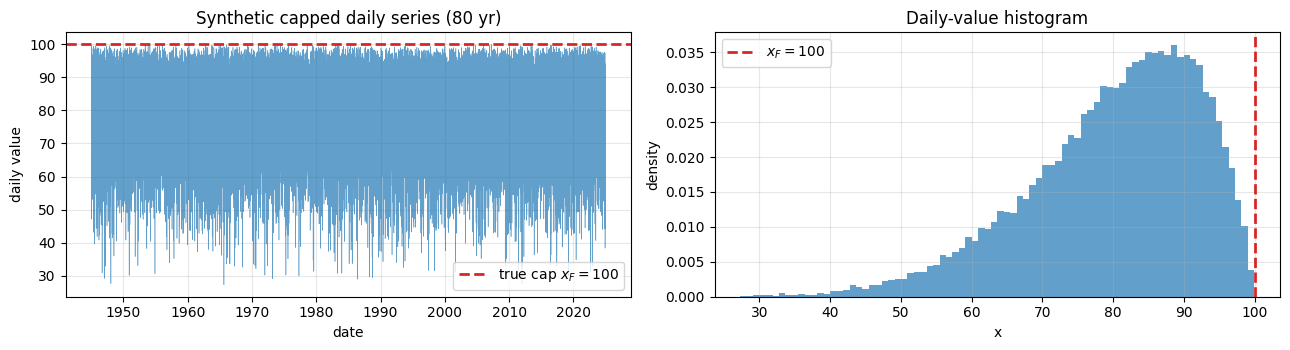

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)
X_F_TRUE = 100.0

dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
beta_draws = RNG.beta(a=8.0, b=2.0, size=n)
daily = X_F_TRUE * beta_draws

series = xr.DataArray(daily, dims="time", coords={"time": dates})

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(series.time, series.values, lw=0.4, alpha=0.7, color="tab:blue")
axes[0].axhline(
    X_F_TRUE, color="tab:red", lw=2, ls="--", label=rf"true cap $x_F = {X_F_TRUE:.0f}$"
)
axes[0].set_title("Synthetic capped daily series (80 yr)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("daily value")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(daily, bins=80, color="tab:blue", alpha=0.7, density=True)
axes[1].axvline(
    X_F_TRUE, color="tab:red", lw=2, ls="--", label=rf"$x_F = {X_F_TRUE:.0f}$"
)
axes[1].set_title("Daily-value histogram")
axes[1].set_xlabel("x")
axes[1].set_ylabel("density")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Annual block maxima

Annual maxima cluster *just below* the cap. With 365 daily draws per year, the empirical distribution of the maxima already shows the tell-tale Weibull shape: a sharp drop-off at the right and a long left tail.

Number of annual maxima: 80
Range: 97.676 to 99.925
True cap: 100.0


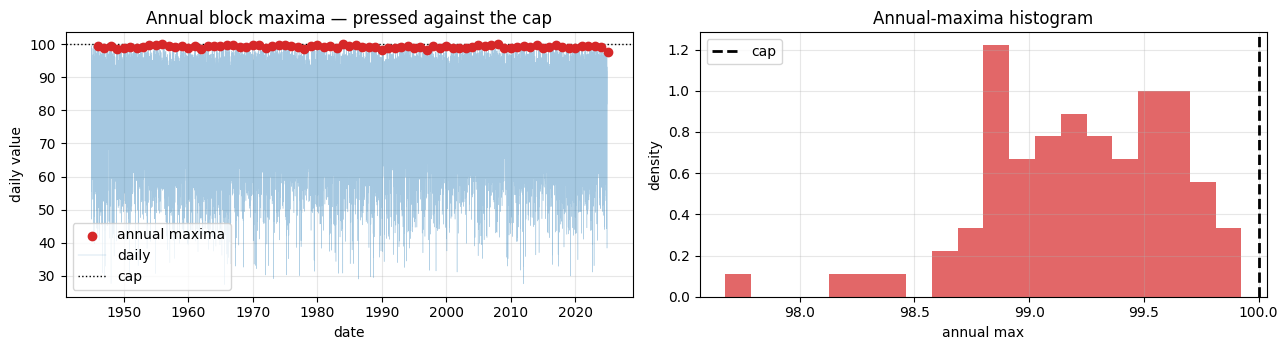

In [5]:
annual_max = temporal_block_maxima(series, freq="YE", min_periods=300).dropna("time")
maxima = jnp.asarray(annual_max.values)
print(f"Number of annual maxima: {annual_max.sizes['time']}")
print(f"Range: {float(maxima.min()):.3f} to {float(maxima.max()):.3f}")
print(f"True cap: {X_F_TRUE:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].scatter(
    annual_max.time, annual_max.values, color="tab:red", zorder=3, label="annual maxima"
)
axes[0].plot(
    series.time, series.values, lw=0.3, alpha=0.4, color="tab:blue", label="daily"
)
axes[0].axhline(X_F_TRUE, color="black", lw=1, ls=":", label="cap")
axes[0].set_title("Annual block maxima — pressed against the cap")
axes[0].set_xlabel("date")
axes[0].set_ylabel("daily value")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(np.asarray(maxima), bins=20, color="tab:red", alpha=0.7, density=True)
axes[1].axvline(X_F_TRUE, color="black", lw=2, ls="--", label="cap")
axes[1].set_title("Annual-maxima histogram")
axes[1].set_xlabel("annual max")
axes[1].set_ylabel("density")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Bayesian Weibull fit

`WeibullType3GEVD` constrains `concentration` to be *negative* in its `arg_constraints`. We use that strict constraint to encode our prior knowledge that the parent is bounded above.

**Priors.**
- $\mu \sim \mathcal{N}(\bar z,\, s_z)$: the empirical mean of the maxima — for $\xi < 0$ the support extends *above* $\mu$, so this is a benign default.
- $\sigma \sim \mathrm{HalfNormal}(2 s_z)$: positive.
- $\xi$: we transform $\eta \sim \mathrm{HalfNormal}(0.4)$ and let $\xi = -\eta$ so that $\xi < 0$ is enforced. The half-normal puts $\sim 95\%$ mass on $\eta \in (0, 0.8)$, i.e. $\xi \in (-0.8, 0)$ — physically reasonable.

In [6]:
mu_loc = float(maxima.mean())
sigma_loc = float(maxima.std())


def weibull_model(maxima, mu_prior_loc, sigma_prior_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_prior_loc, sigma_prior_scale))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale * 2))
    eta = numpyro.sample("eta", ndist.HalfNormal(0.4))
    xi = numpyro.deterministic("xi", -eta)
    numpyro.sample(
        "obs",
        WeibullType3GEVD(loc=mu, scale=sigma, concentration=xi),
        obs=maxima,
    )


kernel = NUTS(weibull_model, target_accept_prob=0.99, init_strategy=init_to_median)
mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False)
mcmc.run(KEY, maxima=maxima, mu_prior_loc=mu_loc, sigma_prior_scale=sigma_loc)
mcmc.print_summary(prob=0.95)
posterior_w = mcmc.get_samples()


                mean       std    median      2.5%     97.5%     n_eff     r_hat
       eta      0.49      0.07      0.49      0.37      0.63    975.29      1.00
        mu     99.10      0.06     99.10     99.00     99.22   1098.85      1.00
     sigma      0.46      0.04      0.45      0.38      0.54    974.35      1.00

Number of divergences: 290


## 5. The headline quantity: posterior on the upper endpoint

The most physically meaningful summary of a Weibull fit is the upper endpoint

$$
x_{\sup} \;=\; \mu - \sigma/\xi \;=\; \mu + \sigma/\eta.
$$

We compute it for every posterior sample. The posterior on $x_{\sup}$ should concentrate near the true cap $x_F = 100$.

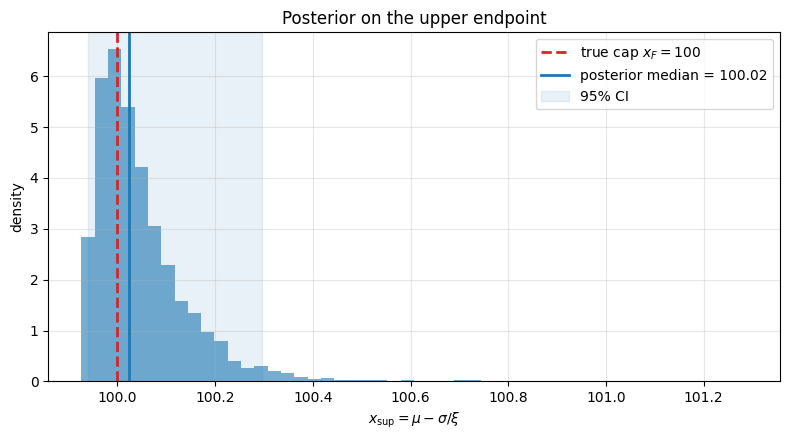

Upper endpoint posterior median: 100.02
95% credible interval:           [99.94, 100.30]
True cap:                        100.0


In [7]:
x_sup = posterior_w["mu"] + posterior_w["sigma"] / posterior_w["eta"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.asarray(x_sup), bins=50, density=True, color="tab:blue", alpha=0.6)
ax.axvline(
    X_F_TRUE, color="tab:red", lw=2, ls="--", label=rf"true cap $x_F = {X_F_TRUE:.0f}$"
)
ax.axvline(
    float(jnp.median(x_sup)),
    color="tab:blue",
    lw=2,
    label=f"posterior median = {float(jnp.median(x_sup)):.2f}",
)
q = jnp.quantile(x_sup, jnp.array([0.025, 0.975]))
ax.axvspan(float(q[0]), float(q[1]), color="tab:blue", alpha=0.1, label="95% CI")
ax.set_xlabel(r"$x_{\sup} = \mu - \sigma/\xi$")
ax.set_ylabel("density")
ax.set_title("Posterior on the upper endpoint")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Upper endpoint posterior median: {float(jnp.median(x_sup)):.2f}")
print(f"95% credible interval:           [{float(q[0]):.2f}, {float(q[1]):.2f}]")
print(f"True cap:                        {X_F_TRUE}")

**Reading this.** The posterior on $x_{\sup}$ is the Bayesian way to ask "where is the cap?" — the upper credible bound is what you would conservatively report as the design value. With 80 years of data the credible band is a few percent wide.

## 6. Misspecified Gumbel for comparison

A practitioner who ignores the bounded-tail nature of the data and fits a Gumbel ($\xi = 0$) gets a return-level curve that *keeps climbing* in $\log T$ — past the actual physical cap.

In [8]:
def gumbel_model(maxima, mu_prior_loc, sigma_prior_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_prior_loc, sigma_prior_scale))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale * 2))
    numpyro.sample("obs", GumbelType1GEVD(loc=mu, scale=sigma), obs=maxima)


kernel_g = NUTS(gumbel_model, target_accept_prob=0.99, init_strategy=init_to_median)
mcmc_g = MCMC(
    kernel_g, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False
)
mcmc_g.run(KEY, maxima=maxima, mu_prior_loc=mu_loc, sigma_prior_scale=sigma_loc)
posterior_g = mcmc_g.get_samples()

## 7. Return-level comparison

This is the punchline. Both fits agree on the bulk; the Weibull curve flattens to the cap, the Gumbel curve runs straight through it.

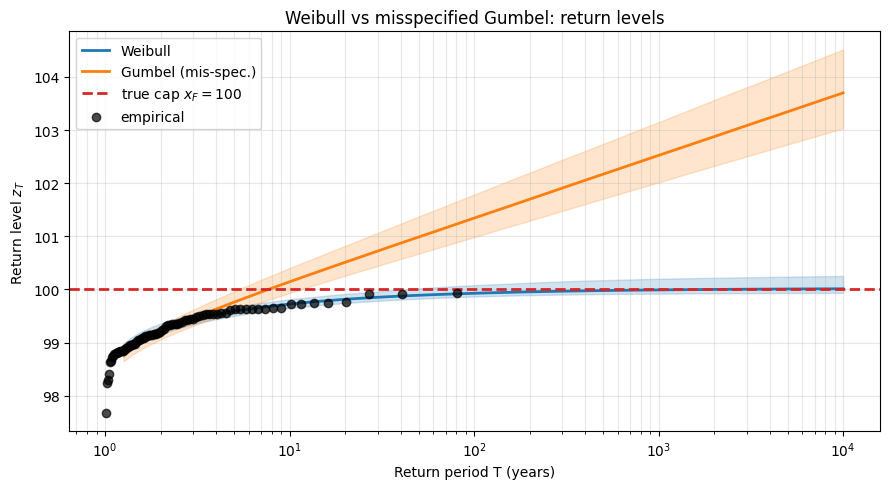

Period at right edge:                                  T = 10000
  Weibull return level (posterior median):             100.01
  Gumbel  return level (posterior median):             103.70
  True cap:                                            100.0
  Gumbel over-prediction past the cap:                  +3.70


In [9]:
periods = jnp.logspace(0.1, 4, 100)


def rl_weibull(mu, sigma, xi):
    return WeibullType3GEVD(loc=mu, scale=sigma, concentration=xi).return_level(periods)


def rl_gumbel(mu, sigma):
    return GumbelType1GEVD(loc=mu, scale=sigma).return_level(periods)


rl_w = jax.vmap(rl_weibull)(posterior_w["mu"], posterior_w["sigma"], posterior_w["xi"])
rl_g = jax.vmap(rl_gumbel)(posterior_g["mu"], posterior_g["sigma"])

n_max = len(maxima)
sorted_max = np.sort(np.asarray(maxima))
emp_periods = (n_max + 1) / np.arange(n_max, 0, -1)

fig, ax = plt.subplots(figsize=(9, 5))
for rl, color, label in [
    (rl_w, "tab:blue", "Weibull"),
    (rl_g, "tab:orange", "Gumbel (mis-spec.)"),
]:
    med = jnp.median(rl, axis=0)
    lo = jnp.quantile(rl, 0.025, axis=0)
    hi = jnp.quantile(rl, 0.975, axis=0)
    ax.fill_between(periods, lo, hi, alpha=0.2, color=color)
    ax.plot(periods, med, color=color, lw=2, label=label)
ax.axhline(
    X_F_TRUE, color="tab:red", lw=2, ls="--", label=rf"true cap $x_F = {X_F_TRUE:.0f}$"
)
ax.scatter(
    emp_periods, sorted_max, color="black", zorder=3, label="empirical", alpha=0.7
)
ax.set_xscale("log")
ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Return level $z_T$")
ax.set_title("Weibull vs misspecified Gumbel: return levels")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

med_w_long = float(jnp.median(rl_w[:, -1]))
med_g_long = float(jnp.median(rl_g[:, -1]))
print(
    f"Period at right edge:                                  T = {float(periods[-1]):.0f}"
)
print(f"  Weibull return level (posterior median):             {med_w_long:.2f}")
print(f"  Gumbel  return level (posterior median):             {med_g_long:.2f}")
print(f"  True cap:                                            {X_F_TRUE}")
print(
    f"  Gumbel over-prediction past the cap:                  {(med_g_long - X_F_TRUE):+.2f}"
)

**Interpretation.** The Weibull fit says "no matter how long you wait, the value cannot exceed the cap" — the curve flattens. The Gumbel fit cannot represent that constraint and produces nonsensical predictions for $T \gtrsim 100$ years, sailing well past the physical limit. In a reliability context this is the difference between a *safe* design and an *over-conservative* (and probably unbuildable) one.

## 8. Posterior on the shape parameter

The Weibull posterior on $\xi$ should be firmly negative — that is, after all, the defining trait. We plot it alongside zero (the Gumbel boundary).

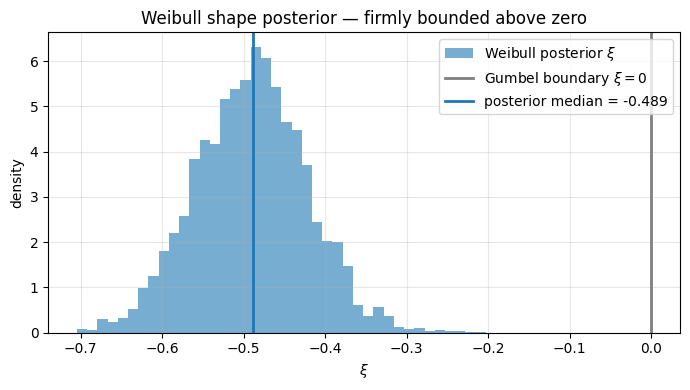

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    np.asarray(posterior_w["xi"]),
    bins=40,
    density=True,
    color="tab:blue",
    alpha=0.6,
    label=r"Weibull posterior $\xi$",
)
ax.axvline(0.0, color="tab:gray", lw=2, label=r"Gumbel boundary $\xi = 0$")
ax.axvline(
    float(jnp.median(posterior_w["xi"])),
    color="tab:blue",
    lw=2,
    label=f"posterior median = {float(jnp.median(posterior_w['xi'])):.3f}",
)
ax.set_xlabel(r"$\xi$")
ax.set_ylabel("density")
ax.set_title("Weibull shape posterior — firmly bounded above zero")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **Bounded extremes need $\xi < 0$.** The Weibull posterior concentrates well inside the negative half-line; the upper endpoint $\mu - \sigma/\xi$ is the practical headline quantity.
- **The cap is identifiable.** With 80 years of data and a parent that frequently approaches the boundary, the posterior on $x_{\sup}$ is a few-percent-wide credible band centred on the truth.
- **Misspecification is *visible*.** The Gumbel return-level curve that runs past the physical cap is a self-diagnostic: any time a return-level extrapolation exceeds a hard physical limit, the model is wrong, not the limit.
- **`WeibullType3GEVD` constrains $\xi < 0$ structurally.** Use it whenever you have prior reason to believe the parent has a finite right endpoint; the constraint stabilises the fit and removes a degree of freedom that the data may not pin down well on its own.

This concludes the three-regime tour (Gumbel / Fréchet / Weibull). The next two notebooks shift gears to the *peaks-over-threshold* parameterisation via the Generalized Pareto Distribution.